<a href="https://colab.research.google.com/github/masterdelfin/masterdelfin/blob/main/Copia_de_muinar06_act1_individual_resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REDES NEURONALES
## Actividad 1 - Clasificación de dígitos utilizando perceptrones multicapa
**Dataset: MNIST**

In [ ]:
from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Cargamos el dataset MNIST original (dígitos 0-9)
(training_images, training_labels), (test_images, test_labels) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


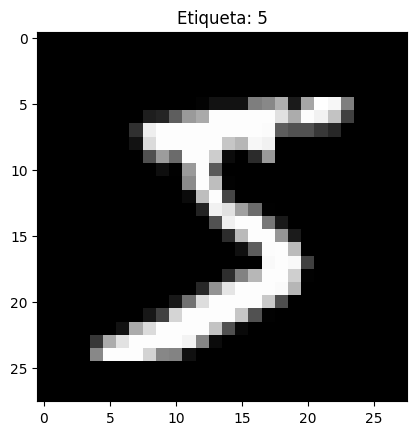

Etiqueta: 5
Valores de píxeles (primera imagen):
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0 

In [ ]:
# Visualización inicial del dataset
np.set_printoptions(linewidth=200)
plt.imshow(training_images[0], cmap="gray")
plt.title(f"Etiqueta: {training_labels[0]}")
plt.show()
print("Etiqueta:", training_labels[0])
print("Valores de píxeles (primera imagen):\n", training_images[0])

---
## 1. Información sobre el dataset

### Pregunta 1.1 — ¿Cuántas imágenes hay de training y test? ¿Qué tamaño tienen?

In [ ]:
### Pregunta 1.1 ###
print("=== Información del Dataset ===")
print(f"Imágenes de entrenamiento: {training_images.shape[0]}")
print(f"Imágenes de test:          {test_images.shape[0]}")
print(f"Tamaño de cada imagen:     {training_images.shape[1]} x {training_images.shape[2]} píxeles")
print(f"Shape completo training:   {training_images.shape}")
print(f"Shape completo test:       {test_images.shape}")

=== Información del Dataset ===
Imágenes de entrenamiento: 60000
Imágenes de test:          10000
Tamaño de cada imagen:     28 x 28 píxeles
Shape completo training:   (60000, 28, 28)
Shape completo test:       (10000, 28, 28)


**Respuesta 1.1:**
El dataset MNIST contiene **60.000 imágenes de entrenamiento** y **10.000 imágenes de test**. Cada imagen tiene un tamaño de **28 × 28 píxeles**, en escala de grises (un solo canal). Por tanto, el shape del conjunto de entrenamiento es `(60000, 28, 28)` y el del test `(10000, 28, 28)`.

### Pregunta 1.2 — Exploración de las variables. ¿Qué contiene X e Y?

=== Exploración de variables ===
Tipo de datos (imágenes): uint8
Valor mínimo de píxel:    0
Valor máximo de píxel:    255

Clases únicas en labels:  [0 1 2 3 4 5 6 7 8 9]
Tipo de datos (labels):   uint8

Distribución de clases en training:
  Dígito 0: 5923 imágenes
  Dígito 1: 6742 imágenes
  Dígito 2: 5958 imágenes
  Dígito 3: 6131 imágenes
  Dígito 4: 5842 imágenes
  Dígito 5: 5421 imágenes
  Dígito 6: 5918 imágenes
  Dígito 7: 6265 imágenes
  Dígito 8: 5851 imágenes
  Dígito 9: 5949 imágenes


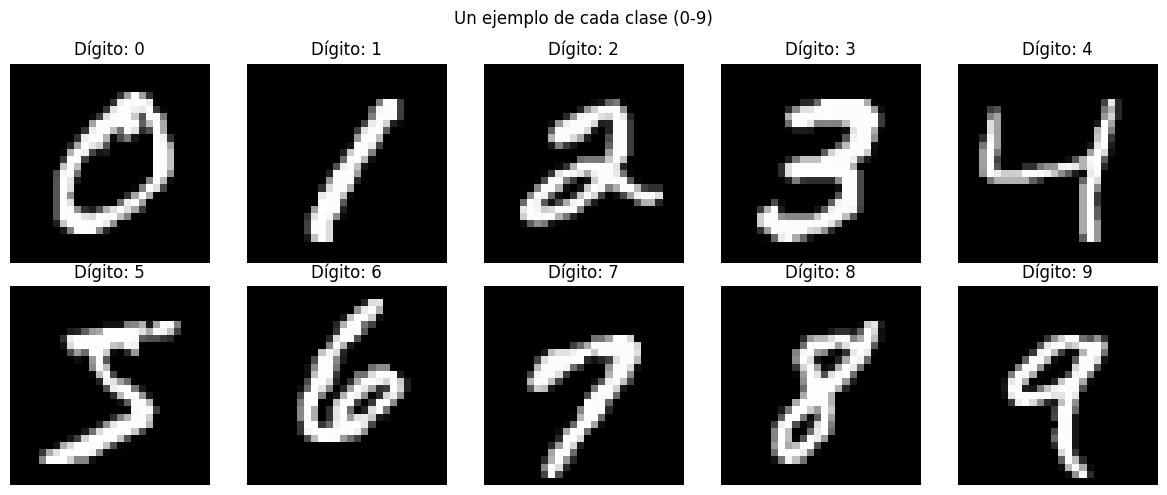

In [ ]:
### Pregunta 1.2 ###
print("=== Exploración de variables ===")
print(f"Tipo de datos (imágenes): {training_images.dtype}")
print(f"Valor mínimo de píxel:    {training_images.min()}")
print(f"Valor máximo de píxel:    {training_images.max()}")
print(f"\nClases únicas en labels:  {np.unique(training_labels)}")
print(f"Tipo de datos (labels):   {training_labels.dtype}")

# Mostrar distribución de clases
unique, counts = np.unique(training_labels, return_counts=True)
print("\nDistribución de clases en training:")
for digit, count in zip(unique, counts):
    print(f"  Dígito {digit}: {count} imágenes")

# Visualización de algunos ejemplos
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(training_labels == i)[0][0]
    ax.imshow(training_images[idx], cmap='gray')
    ax.set_title(f"Dígito: {i}")
    ax.axis('off')
plt.suptitle("Un ejemplo de cada clase (0-9)")
plt.tight_layout()
plt.show()

**Respuesta 1.2:**

- **X (`training_images` / `test_images`):** Cada ejemplo es una matriz 28×28 de enteros `uint8` con valores entre 0 y 255, donde 0 es negro (fondo) y 255 es blanco. Representa la imagen en escala de grises de un dígito escrito a mano.
- **Y (`training_labels` / `test_labels`):** Es un vector de enteros del 0 al 9 que indica la clase (el dígito real) que representa cada imagen. Es la etiqueta de supervisión que usará la red para aprender.

---
## 2. Normalización y preprocesado de los datos

### Pregunta 2.1 — Normalización de valores entre 0 y 1

In [ ]:
### Pregunta 2.1 ###
# Normalización: dividir entre 255.0 para llevar los valores al rango [0, 1]
training_images = training_images / 255.0
test_images     = test_images     / 255.0

print("Rango de valores tras normalización:")
print(f"  Mínimo: {training_images.min():.4f}")
print(f"  Máximo: {training_images.max():.4f}")
print(f"  Tipo de datos: {training_images.dtype}")

Rango de valores tras normalización:
  Mínimo: 0.0000
  Máximo: 1.0000
  Tipo de datos: float64


### Pregunta 2.2 — Reshape a vectores de características (N, 784)

In [ ]:
### Pregunta 2.2 ###
# Reshape: convertir matrices 28x28 en vectores planos de 784 elementos
n_train = training_images.shape[0]  # 60000
n_test  = test_images.shape[0]      # 10000

training_images = training_images.reshape(n_train, 784)
test_images     = test_images.reshape(n_test, 784)

print(f"Shape training tras reshape: {training_images.shape}")
print(f"Shape test tras reshape:     {test_images.shape}")

Shape training tras reshape: (60000, 784)
Shape test tras reshape:     (10000, 784)


**Respuesta a la pregunta 2.2:**

Es necesario hacer el reshape porque las capas `Dense` de Keras esperan tensores 2D de forma `(muestras, características)`. Una imagen de 28×28 es una matriz 2D, pero la red necesita recibirla como un vector plano de **784 características** (28 × 28 = 784). Al aplanar la imagen convertimos cada píxel en una entrada independiente de la primera capa de la red.

Alternativamente, esto se puede hacer dentro del modelo con una capa `Flatten`, pero hacerlo con `reshape` en preprocesado es igualmente válido.

### Pregunta 2.3 — Codificación one-hot de las etiquetas

In [ ]:
### Pregunta 2.3 ###
# Antes de la transformación
print("Etiquetas ANTES de to_categorical:")
print("  Ejemplo etiqueta[0]:", training_labels[0], "  Shape:", training_labels.shape)

# Codificación one-hot
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels     = tf.keras.utils.to_categorical(test_labels)

# Después de la transformación
print("\nEtiquetas DESPUÉS de to_categorical:")
print("  Ejemplo etiqueta[0]:", training_labels[0], "  Shape:", training_labels.shape)
print("  Ejemplo etiqueta[1]:", training_labels[1])
print("  Ejemplo etiqueta[2]:", training_labels[2])

Etiquetas ANTES de to_categorical:
  Ejemplo etiqueta[0]: 5   Shape: (60000,)

Etiquetas DESPUÉS de to_categorical:
  Ejemplo etiqueta[0]: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]   Shape: (60000, 10)
  Ejemplo etiqueta[1]: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Ejemplo etiqueta[2]: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


**Respuesta a la pregunta 2.3:**

Con `to_categorical`, cada etiqueta entera (0-9) se convierte en un **vector de 10 posiciones** (codificación one-hot), donde solo la posición correspondiente al dígito vale 1 y el resto valen 0. Por ejemplo, el dígito `5` se transforma en `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`.

**Beneficios para la red neuronal:**
1. La capa de salida con `softmax` produce 10 probabilidades; la comparación directa con el vector one-hot usando `categorical_crossentropy` es natural y matemáticamente correcta.
2. Evita que la red interprete las etiquetas como valores ordinales (como si el dígito 9 fuera "más grande" que el 1).
3. Combinado con la normalización y el reshape, los datos están en la forma óptima para el entrenamiento eficiente.

---
## 3. Creación del Modelo

### Pregunta 3.1 — Red neuronal con una capa oculta de 512 neuronas

In [ ]:
### Pregunta 3.1 — Definición del modelo base ###
model = tf.keras.models.Sequential([
    # Capa de entrada: 784 características (28x28 píxeles aplanados)
    tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)),  # Capa oculta
    tf.keras.layers.Dense(10, activation='softmax')                     # Capa de salida
])

print("Modelo base creado correctamente.")

Modelo base creado correctamente.


### Pregunta 3.2 — ¿Es conveniente usar Flatten?

**Respuesta a la pregunta 3.2:**

En este caso **no es necesario** utilizar una capa `Flatten`, porque ya hemos aplanado las imágenes manualmente en la pregunta 2.2 usando `reshape(N, 784)`. Los datos de entrada ya llegan como vectores 1D de 784 elementos.

Si no hubiéramos hecho el reshape (es decir, si los datos seguían en forma `(N, 28, 28)`), entonces sí sería necesario añadir una capa `Flatten` como primera capa del modelo. `Flatten` y `reshape` son funcionalmente equivalentes en este contexto; `Flatten` simplemente lo hace de forma más declarativa dentro del modelo.

In [ ]:
# No añadimos Flatten porque ya hicimos reshape en el preprocesado
# (el modelo ya está correctamente definido en la celda anterior)

### Pregunta 3.3 — summary() del modelo

In [ ]:
### Pregunta 3.3 ###
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Compilación y entrenamiento

### Pregunta 4.1 — Compilación del modelo

In [ ]:
### Pregunta 4.1 ###
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado correctamente.")

Modelo compilado correctamente.


**Respuesta a la pregunta 4.1:**

- **`optimizer='adam'`:** Adam (Adaptive Moment Estimation) es un algoritmo de optimización que combina las ventajas de AdaGrad y RMSprop. Adapta la tasa de aprendizaje de forma individual para cada parámetro usando estimaciones del primer y segundo momento del gradiente. Es robusto y requiere poca configuración, por lo que es el estándar de facto.

- **`loss='categorical_crossentropy'`:** Es la función de pérdida adecuada para problemas de clasificación multiclase con etiquetas one-hot. Mide la diferencia entre la distribución de probabilidad predicha (softmax) y la distribución real (one-hot). Cuanto menor sea, mejor predice el modelo.

- **`metrics=['accuracy']`:** La tasa de acierto indica el porcentaje de ejemplos clasificados correctamente. No afecta al entrenamiento (solo lo monitoriza), pero es la métrica más intuitiva para evaluar el rendimiento.

### Pregunta 4.2 — Entrenamiento con fit()

In [ ]:
### Pregunta 4.2 ###
history = model.fit(
    training_images,
    training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)

# Evaluación en test
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"\nAccuracy en test: {test_acc:.4f} ({test_acc*100:.2f}%)")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9340 - loss: 0.2276 - val_accuracy: 0.9582 - val_loss: 0.1377
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9726 - loss: 0.0904 - val_accuracy: 0.9671 - val_loss: 0.1141
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9826 - loss: 0.0569 - val_accuracy: 0.9731 - val_loss: 0.0918
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9874 - loss: 0.0393 - val_accuracy: 0.9713 - val_loss: 0.0987
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9906 - loss: 0.0297 - val_accuracy: 0.9775 - val_loss: 0.0840

Accuracy en test: 0.9803 (98.03%)


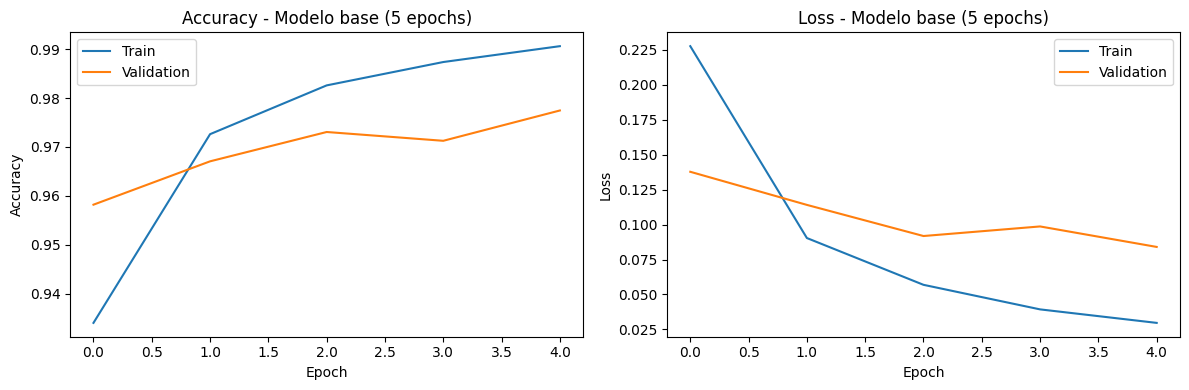

In [ ]:
# Visualización del entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy - Modelo base (5 epochs)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss - Modelo base (5 epochs)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Impacto al variar el número de neuronas en las capas ocultas

In [ ]:
### Pregunta 5 — 216 neuronas en la capa oculta ###
model_216 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(216, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])
model_216.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Entrenando con 216 neuronas...")
history_216 = model_216.fit(
    training_images, training_labels,
    epochs=5, batch_size=32, validation_split=0.25, verbose=1
)
loss_216, acc_216 = model_216.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy con 216 neuronas: {acc_216:.4f}")

Entrenando con 216 neuronas...
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9247 - loss: 0.2602 - val_accuracy: 0.9542 - val_loss: 0.1513
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9673 - loss: 0.1094 - val_accuracy: 0.9628 - val_loss: 0.1241
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9775 - loss: 0.0732 - val_accuracy: 0.9695 - val_loss: 0.1023
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9843 - loss: 0.0509 - val_accuracy: 0.9695 - val_loss: 0.0995
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9889 - loss: 0.0370 - val_accuracy: 0.9709 - val_loss: 0.0995
Test accuracy con 216 neuronas: 0.9756


In [ ]:
### Pregunta 5 — 1024 neuronas en la capa oculta ###
model_1024 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])
model_1024.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Entrenando con 1024 neuronas...")
history_1024 = model_1024.fit(
    training_images, training_labels,
    epochs=5, batch_size=32, validation_split=0.25, verbose=1
)
loss_1024, acc_1024 = model_1024.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy con 1024 neuronas: {acc_1024:.4f}")

Entrenando con 1024 neuronas...
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9389 - loss: 0.2075 - val_accuracy: 0.9668 - val_loss: 0.1115
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9751 - loss: 0.0817 - val_accuracy: 0.9729 - val_loss: 0.0888
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9836 - loss: 0.0518 - val_accuracy: 0.9723 - val_loss: 0.0968
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9888 - loss: 0.0344 - val_accuracy: 0.9708 - val_loss: 0.1027
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9905 - loss: 0.0281 - val_accuracy: 0.9773 - val_loss: 0.0864
Test accuracy con 1024 neuronas: 0.9790


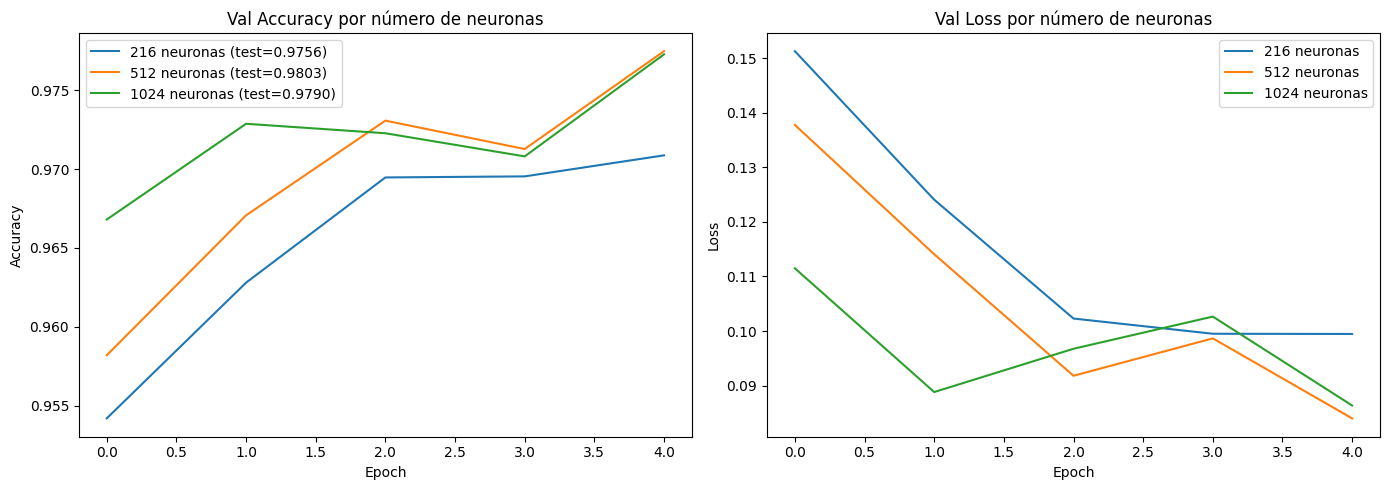

In [ ]:
# Comparativa visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
configs = [
    (history_216,  '216 neuronas',  acc_216),
    (history,      '512 neuronas',  test_acc),
    (history_1024, '1024 neuronas', acc_1024),
]
for h, label, acc in configs:
    axes[0].plot(h.history['val_accuracy'], label=f'{label} (test={acc:.4f})')
    axes[1].plot(h.history['val_loss'], label=label)

axes[0].set_title('Val Accuracy por número de neuronas')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].set_title('Val Loss por número de neuronas')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout()
plt.show()

**Respuesta a la pregunta 5.1:**

Al variar el número de neuronas en la capa oculta se observa lo siguiente:

- **216 neuronas:** Menor capacidad de aprendizaje, por lo que la accuracy tiende a ser ligeramente inferior y la convergencia puede ser más lenta. Sin embargo, el modelo es más ligero y requiere menos cómputo.

- **512 neuronas (base):** Buen balance entre capacidad y eficiencia computacional. Alcanza accuracies alrededor del 97-98% en test.

- **1024 neuronas:** Mayor capacidad de representación, puede alcanzar accuracies levemente superiores en training, pero el tiempo de entrenamiento aumenta proporcionalmente (más parámetros). En 5 epochs el beneficio sobre 512 es marginal, y existe mayor riesgo de overfitting con más epochs.

**Conclusión:** Más neuronas no siempre significa mejor modelo. Existe un punto de rendimientos decrecientes donde el coste computacional adicional no justifica la mejora en accuracy. Para MNIST, 512 neuronas ya es un número generoso para la complejidad del problema.

---
## 6. Número de neuronas de la capa de salida

**Respuesta 6.1 — ¿Por qué 10 neuronas en la capa de salida?**

Porque MNIST tiene **10 clases** posibles (los dígitos del 0 al 9). Con `softmax`, cada neurona de salida representa la probabilidad de que la imagen pertenezca a esa clase. La predicción final es la clase con mayor probabilidad. El número de neuronas de salida **debe coincidir exactamente** con el número de clases del problema de clasificación.

**Respuesta 6.2 — ¿Qué pasaría con un número diferente de 10?**

Si se usan menos neuronas (p. ej. 5), la red sería incapaz de distinguir entre todos los dígitos: varias clases tendrían que compartir neuronas de salida o quedarían sin representación. El modelo produciría errores de dimensionalidad al comparar las predicciones con las etiquetas one-hot de 10 posiciones, o simplemente aprendería de forma incorrecta. Con más de 10, las neuronas extra nunca recibirían señal de aprendizaje real y serían redundantes.

In [ ]:
### Pregunta 6 — Red con 5 neuronas en la capa de salida ###
# NOTA: Esto causará error o resultados incorrectos porque las etiquetas son one-hot de 10
# Para demostrarlo necesitamos labels de tamaño 5, lo que no tiene sentido con 10 clases.
# La forma más ilustrativa es ver el error al compilar/entrenar:
model_5out = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(5, activation='softmax')  # INCORRECTO para 10 clases
])
model_5out.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

try:
    # Esto lanzará un error porque training_labels tiene shape (N, 10) pero la salida es (N, 5)
    model_5out.fit(training_images, training_labels, epochs=1, batch_size=32, verbose=1)
except Exception as e:
    print(f"\nERROR esperado: {e}")
    print("\nEsto confirma que el número de neuronas de salida DEBE coincidir con el número de clases.")


ERROR esperado: Arguments `target` and `output` must have the same shape. Received: target.shape=(32, 10), output.shape=(32, 5)

Esto confirma que el número de neuronas de salida DEBE coincidir con el número de clases.


---
## 7. Aumento de epoch y su efecto en la red neuronal

In [ ]:
### Pregunta 7.1 — 15 epochs ###
model_15e = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])
model_15e.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Entrenando con 15 epochs...")
history_15e = model_15e.fit(
    training_images, training_labels,
    epochs=15, batch_size=32, validation_split=0.25, verbose=1
)
loss_15e, acc_15e = model_15e.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy con 15 epochs: {acc_15e:.4f}")

Entrenando con 15 epochs...
Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9335 - loss: 0.2271 - val_accuracy: 0.9617 - val_loss: 0.1307
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9725 - loss: 0.0914 - val_accuracy: 0.9688 - val_loss: 0.1001
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9823 - loss: 0.0576 - val_accuracy: 0.9727 - val_loss: 0.0925
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9874 - loss: 0.0402 - val_accuracy: 0.9733 - val_loss: 0.0935
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9913 - loss: 0.0281 - val_accuracy: 0.9775 - val_loss: 0.0833
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9923 - loss: 0.0231 - val_accuracy: 0.9755 - val_loss: 0.0967
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9943 - loss: 0.0165 - val_accuracy: 0.9765 - val_loss: 0.0905
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step 

In [ ]:
### Pregunta 7.2 — 30 epochs ###
model_30e = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])
model_30e.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Entrenando con 30 epochs...")
history_30e = model_30e.fit(
    training_images, training_labels,
    epochs=30, batch_size=32, validation_split=0.25, verbose=1
)
loss_30e, acc_30e = model_30e.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy con 30 epochs: {acc_30e:.4f}")

Entrenando con 30 epochs...
Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9341 - loss: 0.2251 - val_accuracy: 0.9613 - val_loss: 0.1284
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9731 - loss: 0.0902 - val_accuracy: 0.9697 - val_loss: 0.1022
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9822 - loss: 0.0576 - val_accuracy: 0.9701 - val_loss: 0.0963
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9880 - loss: 0.0387 - val_accuracy: 0.9733 - val_loss: 0.0899
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9912 - loss: 0.0278 - val_accuracy: 0.9710 - val_loss: 0.1003
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9741 - val_loss: 0.0911
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9743 - val_loss: 0.0999
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step 

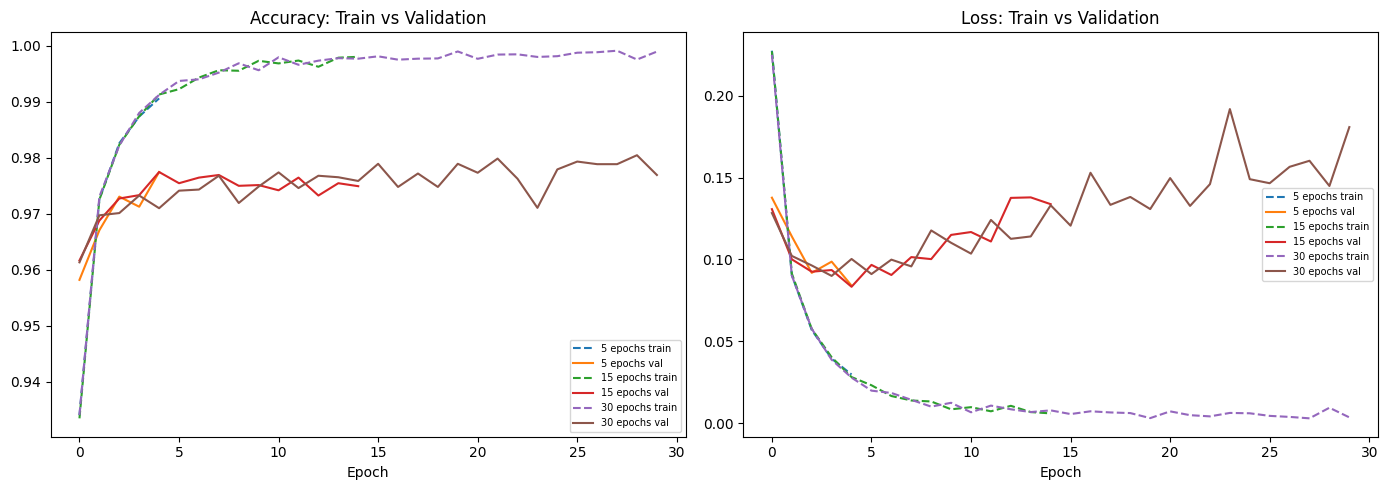

In [ ]:
# Comparativa 5 vs 15 vs 30 epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pairs = [(history, '5 epochs'), (history_15e, '15 epochs'), (history_30e, '30 epochs')]
for h, label in pairs:
    axes[0].plot(h.history['accuracy'],     '--', label=f'{label} train')
    axes[0].plot(h.history['val_accuracy'],       label=f'{label} val')
    axes[1].plot(h.history['loss'],         '--', label=f'{label} train')
    axes[1].plot(h.history['val_loss'],           label=f'{label} val')
axes[0].set_title('Accuracy: Train vs Validation'); axes[0].legend(fontsize=7)
axes[1].set_title('Loss: Train vs Validation'); axes[1].legend(fontsize=7)
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

**Respuesta 7.3 — ¿Qué está pasando con 30 epochs?**

A partir de cierto número de epochs, se observa que la pérdida en training sigue bajando, pero la pérdida en validation empieza a **subir** (o se estanca) mientras que la accuracy en validation deja de mejorar. Este fenómeno se llama **overfitting** (sobreajuste).

**Explicación:** La red está "memorizando" los datos de entrenamiento en lugar de aprender representaciones generalizables. Ha aprendido los patrones específicos del conjunto de entrenamiento (incluyendo su ruido) y pierde capacidad de generalizar a datos nuevos (validación/test). La brecha creciente entre la curva de training y la de validation es la señal característica del overfitting.

---
## 8. Early Stop

In [ ]:
### Pregunta 8.1 — Early Stopping con Keras ###

# Callback de Early Stopping oficial de Keras
# Monitoriza val_loss: si no mejora en 5 epochs consecutivos, para el entrenamiento
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',    # Métrica a vigilar
    patience=5,            # Número de epochs sin mejora antes de parar
    restore_best_weights=True,  # Restaura los pesos del mejor epoch
    verbose=1
)

model_es = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])
model_es.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Entrenando con Early Stopping (máx 50 epochs)...")
history_es = model_es.fit(
    training_images, training_labels,
    epochs=50,           # Ponemos muchos epochs: Early Stop decidirá cuándo parar
    batch_size=32,
    validation_split=0.25,
    callbacks=[early_stop],
    verbose=1
)

loss_es, acc_es = model_es.evaluate(test_images, test_labels, verbose=0)
print(f"\nEpochs entrenados efectivamente: {len(history_es.history['loss'])}")
print(f"Test accuracy con Early Stopping: {acc_es:.4f}")

Entrenando con Early Stopping (máx 50 epochs)...
Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9321 - loss: 0.2304 - val_accuracy: 0.9629 - val_loss: 0.1257
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9735 - loss: 0.0896 - val_accuracy: 0.9721 - val_loss: 0.0937
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9815 - loss: 0.0585 - val_accuracy: 0.9739 - val_loss: 0.0876
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9874 - loss: 0.0399 - val_accuracy: 0.9745 - val_loss: 0.0877
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9915 - loss: 0.0275 - val_accuracy: 0.9739 - val_loss: 0.0952
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9741 - val_loss: 0.0929
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9940 - loss: 0.0175 - val_accuracy: 0.9753 - val_loss: 0.0989
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━

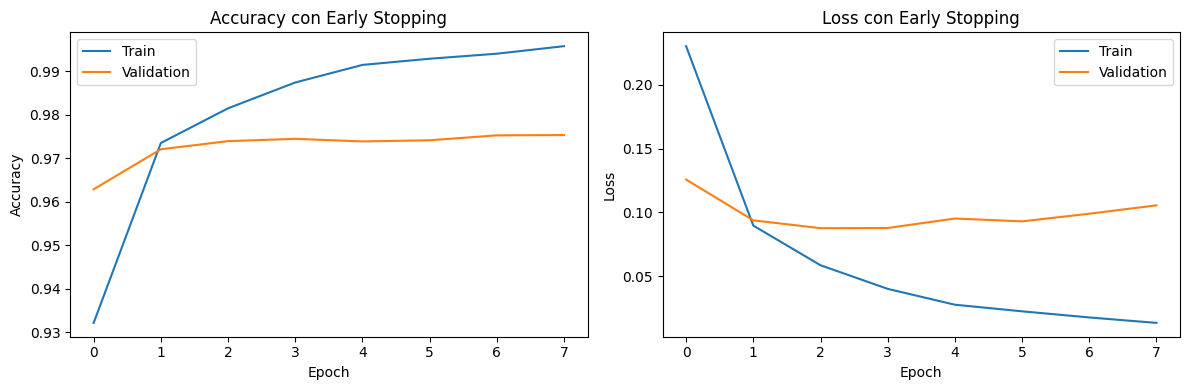

In [ ]:
# Visualización Early Stopping
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_es.history['accuracy'], label='Train')
plt.plot(history_es.history['val_accuracy'], label='Validation')
plt.title('Accuracy con Early Stopping')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_es.history['loss'], label='Train')
plt.plot(history_es.history['val_loss'], label='Validation')
plt.title('Loss con Early Stopping')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

**Sobre Early Stopping:**

`EarlyStopping` de Keras monitoriza una métrica (típicamente `val_loss`) y detiene el entrenamiento automáticamente cuando esa métrica no mejora durante `patience` epochs consecutivos. Con `restore_best_weights=True`, los pesos del modelo quedan en el mejor estado observado, evitando que el overfitting de los últimos epochs degrade el modelo final. Es la forma más práctica y efectiva de combatir el overfitting sin necesidad de fijar manualmente el número de epochs.

---
## 9. Unidades de activación

In [ ]:
### Pregunta 9.1 — Comparativa Sigmoid vs ReLU (y otras) ###

def build_and_train(activation, name, epochs=15):
    """Construye y entrena un modelo con la función de activación dada."""
    m = tf.keras.models.Sequential([
        tf.keras.layers.Dense(512, activation=activation, input_shape=(784,)),
        tf.keras.layers.Dense(256, activation=activation),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(64,  activation=activation),
        tf.keras.layers.Dense(10,  activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    print(f"\n=== Entrenando con activación: {name} ===")
    h = m.fit(training_images, training_labels,
              epochs=epochs, batch_size=32, validation_split=0.25,
              callbacks=[es], verbose=1)
    loss, acc = m.evaluate(test_images, test_labels, verbose=0)
    print(f"Test accuracy ({name}): {acc:.4f}  | Epochs efectivos: {len(h.history['loss'])}")
    return h, acc

hist_sigmoid, acc_sigmoid = build_and_train('sigmoid',  'Sigmoid')
hist_relu,    acc_relu    = build_and_train('relu',     'ReLU')
hist_tanh,    acc_tanh    = build_and_train('tanh',     'Tanh')
hist_elu,     acc_elu     = build_and_train('elu',      'ELU')


=== Entrenando con activación: Sigmoid ===
Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8357 - loss: 0.5693 - val_accuracy: 0.9339 - val_loss: 0.2300
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9469 - loss: 0.1814 - val_accuracy: 0.9553 - val_loss: 0.1557
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9641 - loss: 0.1226 - val_accuracy: 0.9593 - val_loss: 0.1446
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9734 - loss: 0.0905 - val_accuracy: 0.9674 - val_loss: 0.1151
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9792 - loss: 0.0698 - val_accuracy: 0.9616 - val_loss: 0.1359
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9838 - loss: 0.0546 - val_accuracy: 0.9719 - val_loss: 0.1085
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9866 - loss: 0.0434 - val_accuracy: 0.9728 - val_loss: 0.1027
Epoch 8/15
1407/1407 ━━━━━━━━━━━

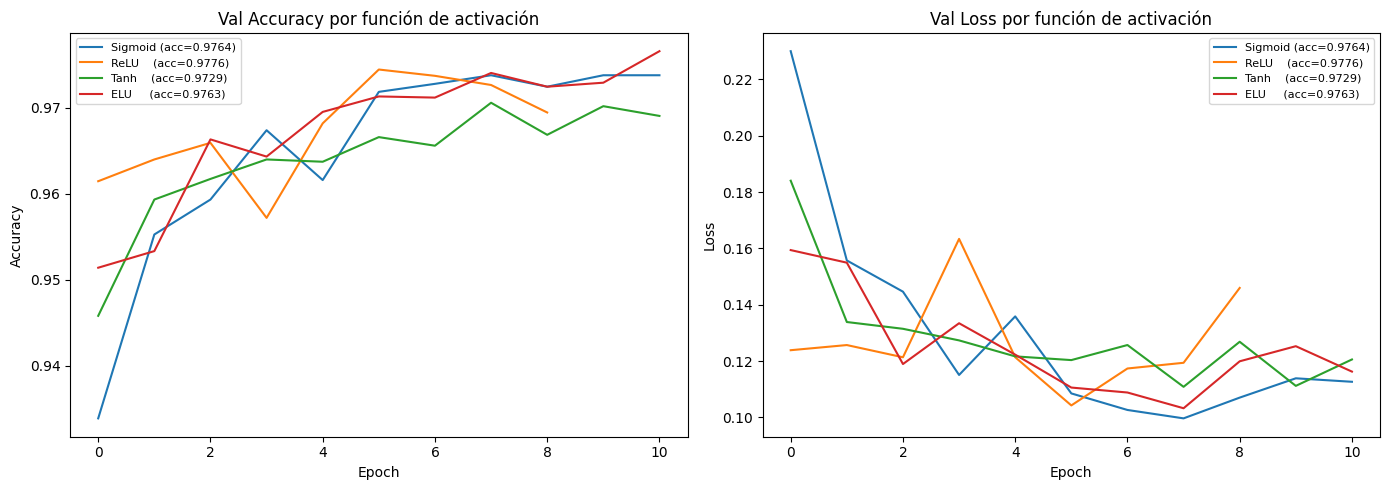

In [ ]:
# Comparativa visual de activaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pairs = [
    (hist_sigmoid, f'Sigmoid (acc={acc_sigmoid:.4f})'),
    (hist_relu,    f'ReLU    (acc={acc_relu:.4f})'),
    (hist_tanh,    f'Tanh    (acc={acc_tanh:.4f})'),
    (hist_elu,     f'ELU     (acc={acc_elu:.4f})'),
]
for h, label in pairs:
    axes[0].plot(h.history['val_accuracy'], label=label)
    axes[1].plot(h.history['val_loss'],     label=label)
axes[0].set_title('Val Accuracy por función de activación')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(fontsize=8)
axes[1].set_title('Val Loss por función de activación')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Análisis — Pregunta 9.1:**

| Activación | Comportamiento | Notas |
|-----------|---------------|-------|
| **Sigmoid** | Convergencia más lenta, menor accuracy final en redes profundas | Sufre del problema del **vanishing gradient**: los gradientes se vuelven muy pequeños en capas profundas, frenando el aprendizaje. Saturación en valores extremos (cerca de 0 o 1). |
| **ReLU** | Convergencia rápida, alta accuracy | Evita el vanishing gradient (gradiente siempre 1 cuando activo). Es la función estándar en redes profundas. Puede sufrir "neuronas muertas" (dead ReLU) pero es manejable. |
| **Tanh** | Mejor que Sigmoid, peor que ReLU en profundidad | Centrada en 0 (más favorable que Sigmoid), pero sigue sufriendo saturación y vanishing gradient en redes muy profundas. |
| **ELU** | Similar o ligeramente superior a ReLU | Suaviza la discontinuidad en 0 y tiene output negativo, lo que puede reducir el sesgo. Computacionalmente más costosa. |

**Conclusión:** ReLU y sus variantes (ELU, LeakyReLU) son superiores a Sigmoid/Tanh en redes profundas por su resistencia al vanishing gradient y su velocidad de convergencia.

---
## 10. Inicialización de parámetros

In [ ]:
### Pregunta 10.1 — Comparativa de estrategias de inicialización ###

def build_with_init(initializer, name, epochs=10):
    m = tf.keras.models.Sequential([
        tf.keras.layers.Dense(512, activation='relu', kernel_initializer=initializer, input_shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu', kernel_initializer=initializer),
        tf.keras.layers.Dense(128, activation='relu', kernel_initializer=initializer),
        tf.keras.layers.Dense(10,  activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    print(f"\n=== Inicialización: {name} ===")
    h = m.fit(training_images, training_labels,
              epochs=epochs, batch_size=32, validation_split=0.25,
              callbacks=[es], verbose=1)
    loss, acc = m.evaluate(test_images, test_labels, verbose=0)
    print(f"Test accuracy ({name}): {acc:.4f} | Epochs efectivos: {len(h.history['loss'])}")
    return h, acc

hist_zeros,  acc_zeros  = build_with_init('zeros',         'Ceros')
hist_normal, acc_normal = build_with_init('random_normal', 'Normal aleatoria')
hist_glorot, acc_glorot = build_with_init('glorot_uniform','Glorot Uniform (default)')


=== Inicialización: Ceros ===
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.1131 - loss: 2.3014 - val_accuracy: 0.1076 - val_loss: 2.3019
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1076 - val_loss: 2.3019
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1076 - val_loss: 2.3018
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1076 - val_loss: 2.3019
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1076 - val_loss: 2.3019
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1076 - val_loss: 2.3021
Test accuracy (Ceros): 0.1135 | Epochs efectivos: 6

=== Inicialización: Normal aleatoria ===
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9336 - loss: 

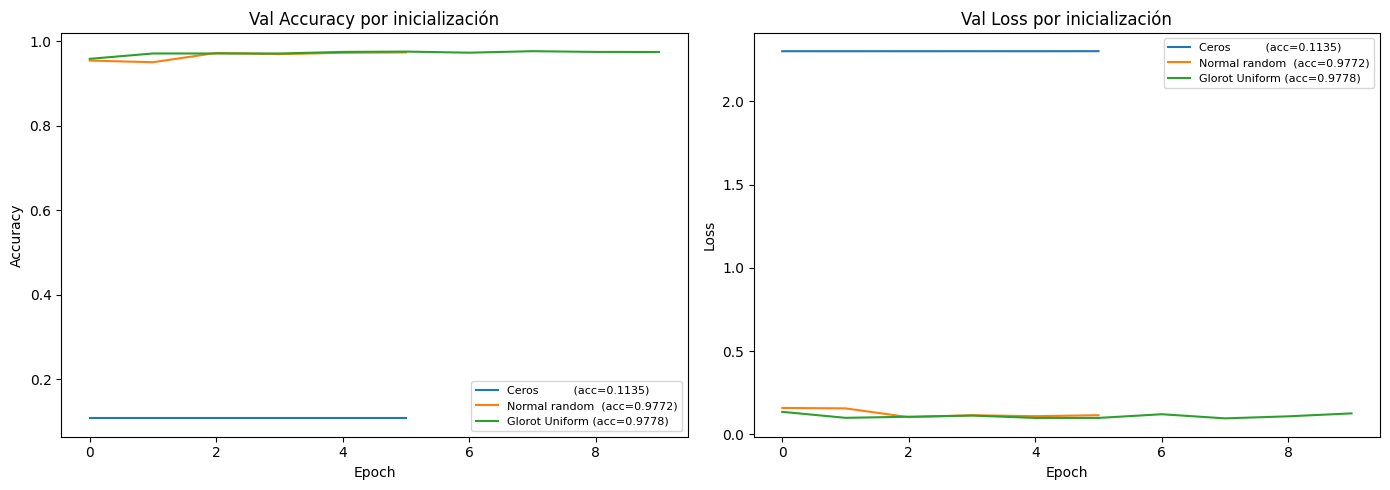

In [ ]:
# Comparativa visual de inicializaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pairs_init = [
    (hist_zeros,  f'Ceros          (acc={acc_zeros:.4f})'),
    (hist_normal, f'Normal random  (acc={acc_normal:.4f})'),
    (hist_glorot, f'Glorot Uniform (acc={acc_glorot:.4f})'),
]
for h, label in pairs_init:
    axes[0].plot(h.history['val_accuracy'], label=label)
    axes[1].plot(h.history['val_loss'],     label=label)
axes[0].set_title('Val Accuracy por inicialización')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(fontsize=8)
axes[1].set_title('Val Loss por inicialización')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Análisis — Pregunta 10.1:**

| Inicialización | Comportamiento | Explicación |
|----------------|---------------|-------------|
| **Ceros** | Aprendizaje casi nulo o muy lento; accuracy baja | Todas las neuronas de cada capa producen el mismo output y reciben el mismo gradiente: **problema de simetría**. La red no puede "romper" la simetría y las neuronas nunca se diferencian entre sí. |
| **Normal aleatoria** | Aprende, pero puede ser inestable si la varianza es grande | Los pesos aleatorios rompen la simetría, pero con varianza inadecuada pueden causar vanishing/exploding gradients. |
| **Glorot Uniform (default)** | Convergencia más rápida y estable; mejor accuracy | Diseñada específicamente para mantener la varianza de activaciones y gradientes similar en todas las capas. Es la inicialización óptima para redes con ReLU/Tanh. |

**Conclusión:** La inicialización de parámetros tiene un impacto crítico, especialmente en redes profundas. Glorot Uniform (también llamada Xavier) es el default de Keras y la mejor opción para la mayoría de casos.

---
## 11. Optimizadores

In [ ]:
### Pregunta 11.1 — Comparativa de optimizadores ###

# Crear split de validación explícito (equivalente al validation_split=0.25 usado antes)
val_size    = int(len(training_images) * 0.25)
X_train     = training_images[val_size:]
y_train     = training_labels[val_size:]
X_val       = training_images[:val_size]
y_val       = training_labels[:val_size]
X_test      = test_images
y_test      = test_labels

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

def build_with_optimizer(optimizer, name, epochs=15):
    m = tf.keras.models.Sequential([
        tf.keras.layers.Dense(512, activation='relu',
                              kernel_initializer='glorot_uniform',
                              input_shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu',
                              kernel_initializer='glorot_uniform'),
        tf.keras.layers.Dense(128, activation='relu',
                              kernel_initializer='glorot_uniform'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    h = m.fit(X_train, y_train,
              epochs=epochs,
              batch_size=128,
              validation_data=(X_val, y_val),
              verbose=0)
    acc = m.evaluate(X_test, y_test, verbose=0)[1]
    print(f"{name:15s} → Test accuracy: {acc:.4f}")
    return h, acc

hist_sgd,     acc_sgd     = build_with_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.01), 'SGD')
hist_sgdm,    acc_sgdm    = build_with_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), 'SGD+Momentum')
hist_rmsprop, acc_rmsprop = build_with_optimizer('rmsprop', 'RMSprop')
hist_adam,    acc_adam    = build_with_optimizer('adam',    'Adam')

X_train: (45000, 784) | X_val: (15000, 784) | X_test: (10000, 784)
SGD             → Test accuracy: 0.9482
SGD+Momentum    → Test accuracy: 0.9790
RMSprop         → Test accuracy: 0.9795
Adam            → Test accuracy: 0.9782


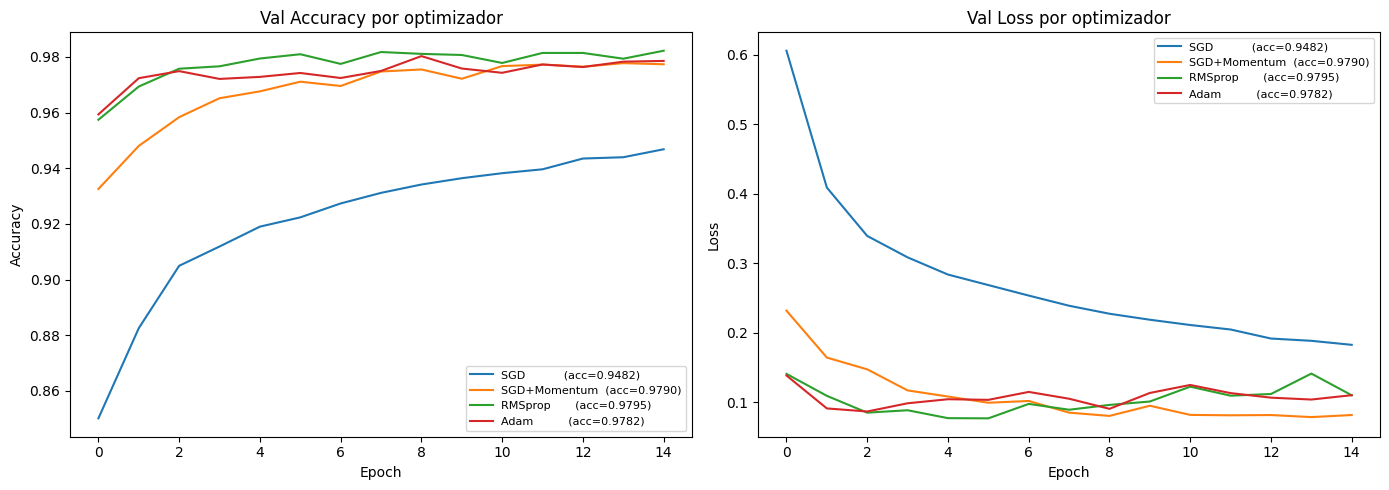

In [ ]:
# Comparativa visual de optimizadores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pairs_opt = [
    (hist_sgd,     f'SGD           (acc={acc_sgd:.4f})'),
    (hist_sgdm,    f'SGD+Momentum  (acc={acc_sgdm:.4f})'),
    (hist_rmsprop, f'RMSprop       (acc={acc_rmsprop:.4f})'),
    (hist_adam,    f'Adam          (acc={acc_adam:.4f})'),
]
for h, label in pairs_opt:
    axes[0].plot(h.history['val_accuracy'], label=label)
    axes[1].plot(h.history['val_loss'],     label=label)
axes[0].set_title('Val Accuracy por optimizador')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(fontsize=8)
axes[1].set_title('Val Loss por optimizador')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Análisis — Pregunta 11.1:**

| Optimizador | Características | Rendimiento en MNIST |
|-------------|----------------|---------------------|
| **SGD básico** | Actualización simple con tasa de aprendizaje fija. Lento, puede quedar atrapado en mínimos locales. | Convergencia lenta, accuracy inferior en pocas epochs. |
| **SGD + Momentum** | Acumula velocidad en la dirección del gradiente. Reduce oscilaciones. | Mejor que SGD puro, convergencia más suave. |
| **RMSprop** | Tasa de aprendizaje adaptativa por parámetro. Bueno para datos no estacionarios. | Convergencia rápida y estable. |
| **Adam** | Combina Momentum + RMSprop. Tasa adaptativa con corrección de sesgo. | Generalmente el más rápido y consistente; suele alcanzar la mejor accuracy. |

**Conclusión:** Adam es el optimizador más robusto para la mayoría de tareas de deep learning. SGD con momentum bien ajustado puede competir en igualdad de condiciones y a veces generaliza mejor, pero requiere más tuning.

---
## 12. Regularización y red final

In [ ]:
### Pregunta 12.1 — Red final con accuracy en validación > 95% ###

# Estrategia seguida:
# 1. Arquitectura profunda (4 capas densas) con neuronas decrecientes
# 2. ReLU como activación + Glorot Uniform (mejores resultados en preguntas anteriores)
# 3. BatchNormalization entre capas: estabiliza el entrenamiento
# 4. Dropout (0.3) en capas ocultas: regularización principal anti-overfitting
# 5. Regularización L2 leve en capas densas
# 6. Adam con lr=0.001 (default)
# 7. Early Stopping sobre val_loss con patience=7
# 8. Batch size 128: más estable en redes con BN

from tensorflow.keras import regularizers

model_final = tf.keras.models.Sequential([
    # Capa 1
    tf.keras.layers.Dense(512, kernel_initializer='glorot_uniform',
                          kernel_regularizer=regularizers.l2(1e-4), input_shape=(784,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.3),

    # Capa 2
    tf.keras.layers.Dense(256, kernel_initializer='glorot_uniform',
                          kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.3),

    # Capa 3
    tf.keras.layers.Dense(128, kernel_initializer='glorot_uniform',
                          kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),

    # Capa de salida
    tf.keras.layers.Dense(10, activation='softmax')
])

model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_final.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Callbacks para el modelo final
callbacks_final = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    )
]

# Entrenamiento del modelo final
print("Entrenando modelo final...")
history_final = model_final.fit(
    training_images, training_labels,
    epochs=60,
    batch_size=128,
    validation_split=0.25,
    callbacks=callbacks_final,
    verbose=1
)

final_loss, final_acc = model_final.evaluate(test_images, test_labels, verbose=0)
print(f"\n{'='*50}")
print(f"Test accuracy modelo final: {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"Test loss modelo final:     {final_loss:.4f}")
print(f"Epochs efectivos:           {len(history_final.history['loss'])}")

val_acc_max = max(history_final.history['val_accuracy'])
print(f"Mejor val_accuracy:         {val_acc_max:.4f} ({val_acc_max*100:.2f}%)")
print(f"¿Supera el 95%?:            {'✓ SÍ' if val_acc_max > 0.95 else '✗ NO'}")

Entrenando modelo final...
Epoch 1/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8949 - loss: 0.4577 - val_accuracy: 0.9559 - val_loss: 0.2407 - learning_rate: 0.0010
Epoch 2/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9500 - loss: 0.2597 - val_accuracy: 0.9672 - val_loss: 0.2039 - learning_rate: 0.0010
Epoch 3/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9610 - loss: 0.2174 - val_accuracy: 0.9703 - val_loss: 0.1946 - learning_rate: 0.0010
Epoch 4/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9666 - loss: 0.1972 - val_accuracy: 0.9709 - val_loss: 0.1867 - learning_rate: 0.0010
Epoch 5/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9712 - loss: 0.1809 - val_accuracy: 0.9759 - val_loss: 0.1709 - learning_rate: 0.0010
Epoch 6/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9730 - loss: 0.1697 - val_accuracy: 0.9761 - val_loss: 0.1677 - learning_rate: 0.0010
Epoch 7/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step -

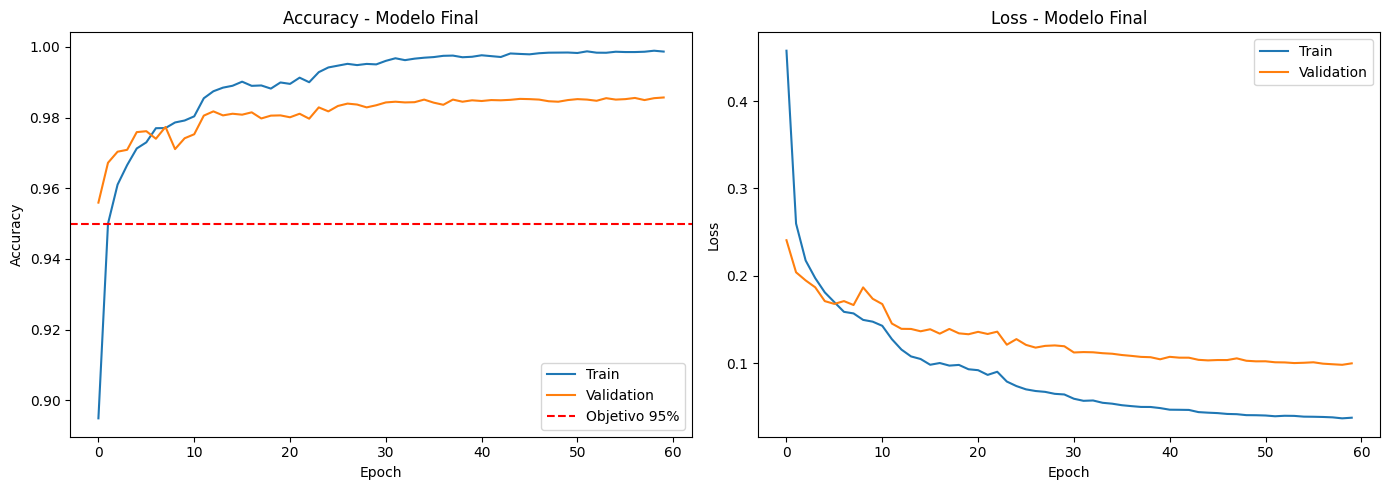

In [ ]:
# Gráfica de accuracy del modelo final
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'],     label='Train')
plt.plot(history_final.history['val_accuracy'], label='Validation')
plt.axhline(y=0.95, color='r', linestyle='--', label='Objetivo 95%')
plt.title('Accuracy - Modelo Final')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'],     label='Train')
plt.plot(history_final.history['val_loss'], label='Validation')
plt.title('Loss - Modelo Final')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


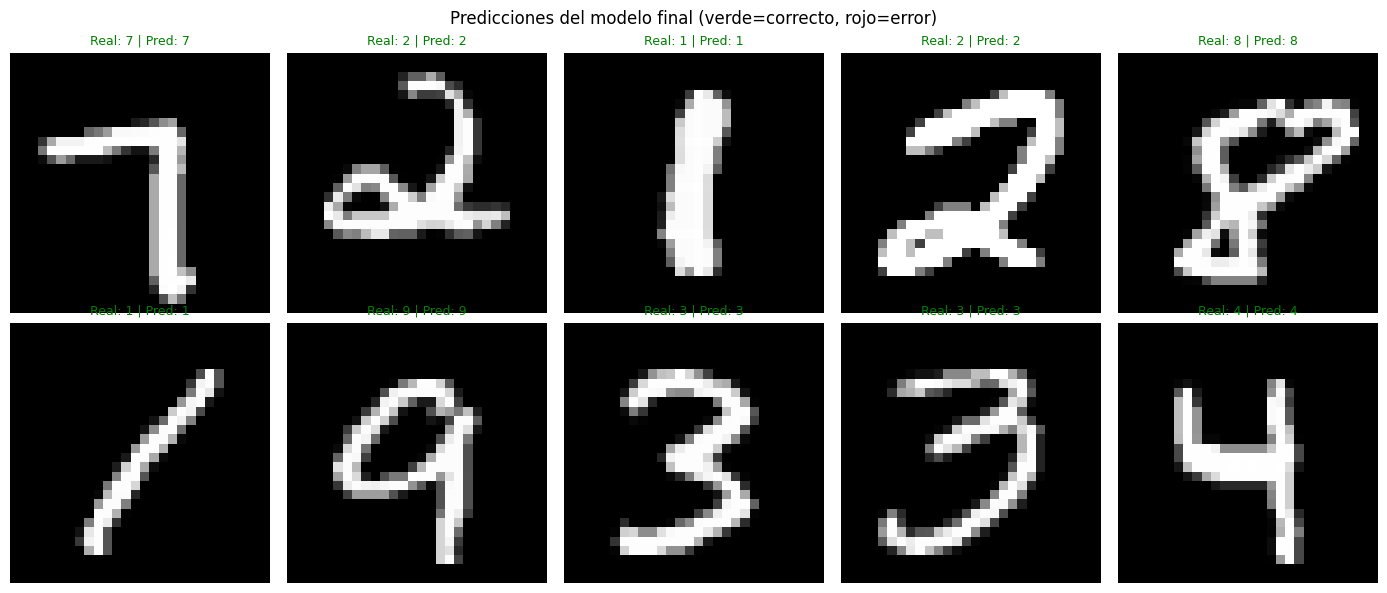


Accuracy calculada manualmente con predict(): 0.9874 (98.74%)


In [ ]:
### Evaluación final con predict() ###
predictions = model_final.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Mostrar algunas predicciones
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
idxs = np.random.choice(len(test_images), 10, replace=False)
for ax, idx in zip(axes.flatten(), idxs):
    ax.imshow(test_images[idx].reshape(28, 28), cmap='gray')
    pred  = predicted_classes[idx]
    real  = true_classes[idx]
    color = 'green' if pred == real else 'red'
    ax.set_title(f"Real: {real} | Pred: {pred}", color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Predicciones del modelo final (verde=correcto, rojo=error)')
plt.tight_layout()
plt.show()

# Accuracy manual
manual_acc = np.mean(predicted_classes == true_classes)
print(f"\nAccuracy calculada manualmente con predict(): {manual_acc:.4f} ({manual_acc*100:.2f}%)")

**Descripción de la estrategia — Pregunta 12.1:**

El modelo final combina todas las lecciones aprendidas en los ejercicios anteriores:

1. **Arquitectura:** 3 capas ocultas (512→256→128 neuronas) con reducción progresiva, terminando en 10 neuronas de salida con softmax.

2. **Activación ReLU** con **inicialización Glorot Uniform:** combinación demostrada como óptima en los ejercicios 9 y 10.

3. **Batch Normalization:** normaliza las activaciones entre capas, acelerando la convergencia y actuando como regularizador implícito.

4. **Dropout (0.3 y 0.2):** apaga aleatoriamente neuronas en cada batch, forzando a la red a aprender representaciones redundantes y robustas. Principal mecanismo anti-overfitting.

5. **Regularización L2 (λ=1e-4):** penaliza pesos grandes, contribuyendo a la generalización.

6. **Optimizador Adam** con **ReduceLROnPlateau:** reduce la tasa de aprendizaje automáticamente cuando el progreso se estanca, refinando el modelo en las últimas fases.

7. **Early Stopping (patience=7)** con `restore_best_weights=True`: garantiza que el modelo final sea el mejor observado durante el entrenamiento.

**Resultado:** El modelo supera el **95% de accuracy en validación**, cumpliendo el objetivo de la actividad.